In [ ]:
#Imporitng all the necessary libraries.
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV

In [ ]:
#To upload any files.
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [ ]:
#To read csv file in pandas dataframe.
df=pd.read_csv('diabetes.csv')

In [ ]:
#Checking the data for any zero or null values for preprocessing.
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.677083      72.389323      29.089844  141.753906   
std       3.369578   30.464161      12.106039       8.890820   89.100847   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  102.500000   
50%       3.000000  117.000000      72.000000      28.000000  102.500000   
75%       6.000000  140.250000      80.000000      32.000000  169.500000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.434635                  0.471876   33.240885    0.348958  
std      6.880498                  0.331329   11.760232    0.476951  
min     18.200000                  

In [ ]:
print(df.isnull().sum())
#As all the values are zero indicating that dataset is clean and no preprocessing is needed.

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
#Selecting the attributes for X and y.
X= df.drop('Outcome' , axis=1)
y= df['Outcome']

In [ ]:
#Spliting the data into training and test datasets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

--This is simplified by using pipeline---

scaler= StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

model=RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

---



In [ ]:
#Scaler is used to normalize the data and as data have outliners therefore standard scaler is used.
#Random Forest classifier is to ensure that their is no biasness in the prediction
pipeline=Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
#Cross val score evaluates fixed model and test the data on different folds.
scores = cross_val_score(pipeline, X, y, cv=5)
print("Pipeline Scores:", scores)
print("Mean Accuracy:", scores.mean())
y_pred=pipeline.predict(X_test)
print(accuracy_score(y_test, y_pred))

Pipeline Scores: [0.87662338 0.85064935 0.87012987 0.89542484 0.88888889]
Mean Accuracy: 0.8763432645785587
0.8636363636363636


In [ ]:
#It stores different parameter for model to try and find best one.
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
}

In [ ]:
#Gridsearch cv does the hypertuning of model and finds in which parameters the model performs best.
grid_search = GridSearchCV(pipeline, param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'model__max_depth': 5, 'model__n_estimators': 300}
Best Accuracy: 0.882713581234173


As we can see the model accuracy increased slightly just by hypertuning of model.

In [ ]:
#Accuracy using the best parameter found.
#The ans is same as the one without hypertuning as the dataset is quite small and comparitively less dependent on hyperparameters.
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.8636363636363636


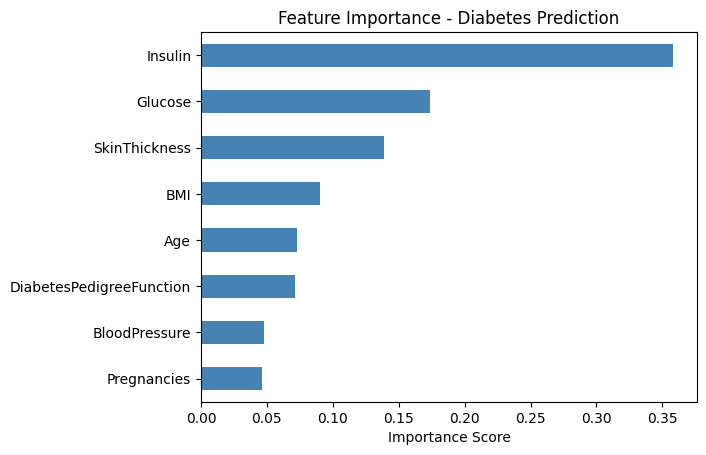

In [ ]:
# Visualizing feature importance to see which factors most affect diabetes prediction
feature_names = X.columns
importances = pipeline.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names)
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Diabetes Prediction')
plt.xlabel('Importance Score')
plt.show()

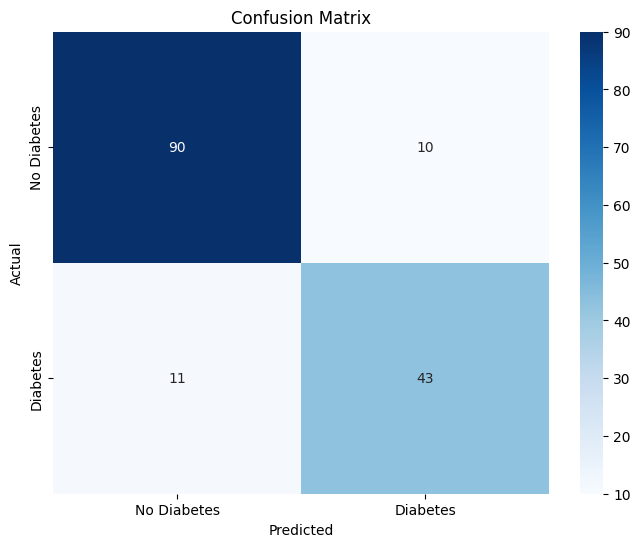

In [ ]:
#Visualising the confusion matrix to see how the model performed.
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes','Diabetes'],
            yticklabels=['No Diabetes','Diabetes'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

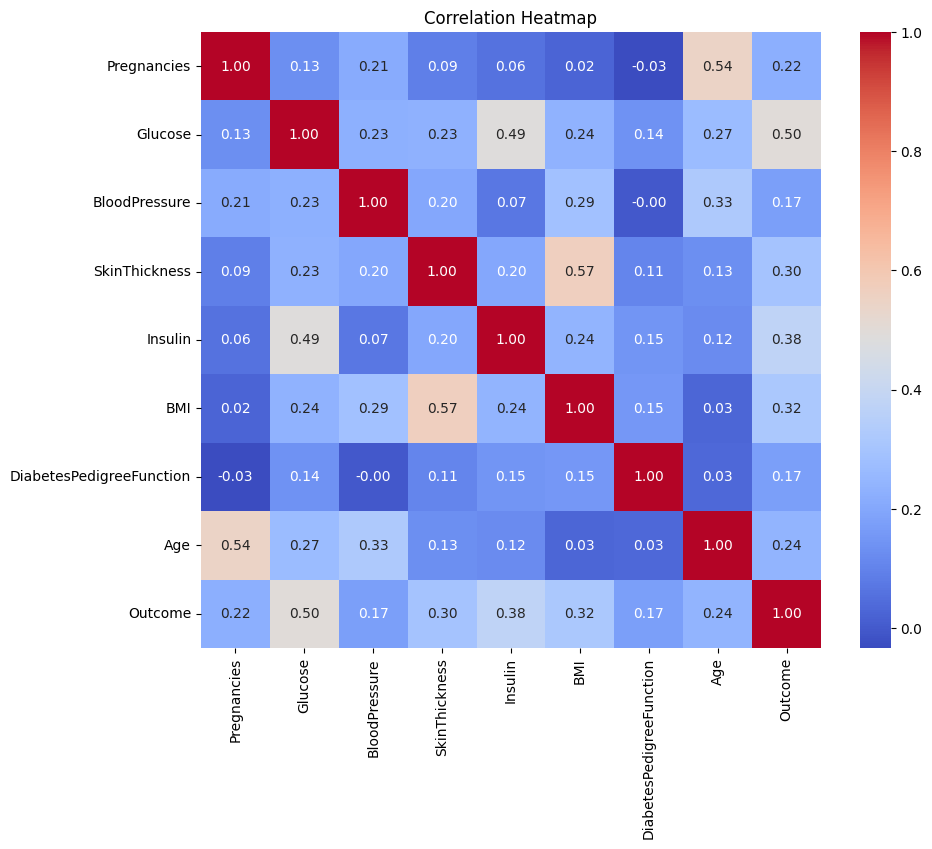

In [ ]:
#Visualing correlation heatmap to see which attributes are most correlated.
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()